In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import math
import utilities

### Distribution of Ending Wealth for Dice Rolls

All in vs. 60% cash

arithmetic average: 3.33%


/var/folders/kd/b8dwm5c57nv693ljw5j_2n_00000gn/T/ipykernel_54235/3921585178.py:70: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


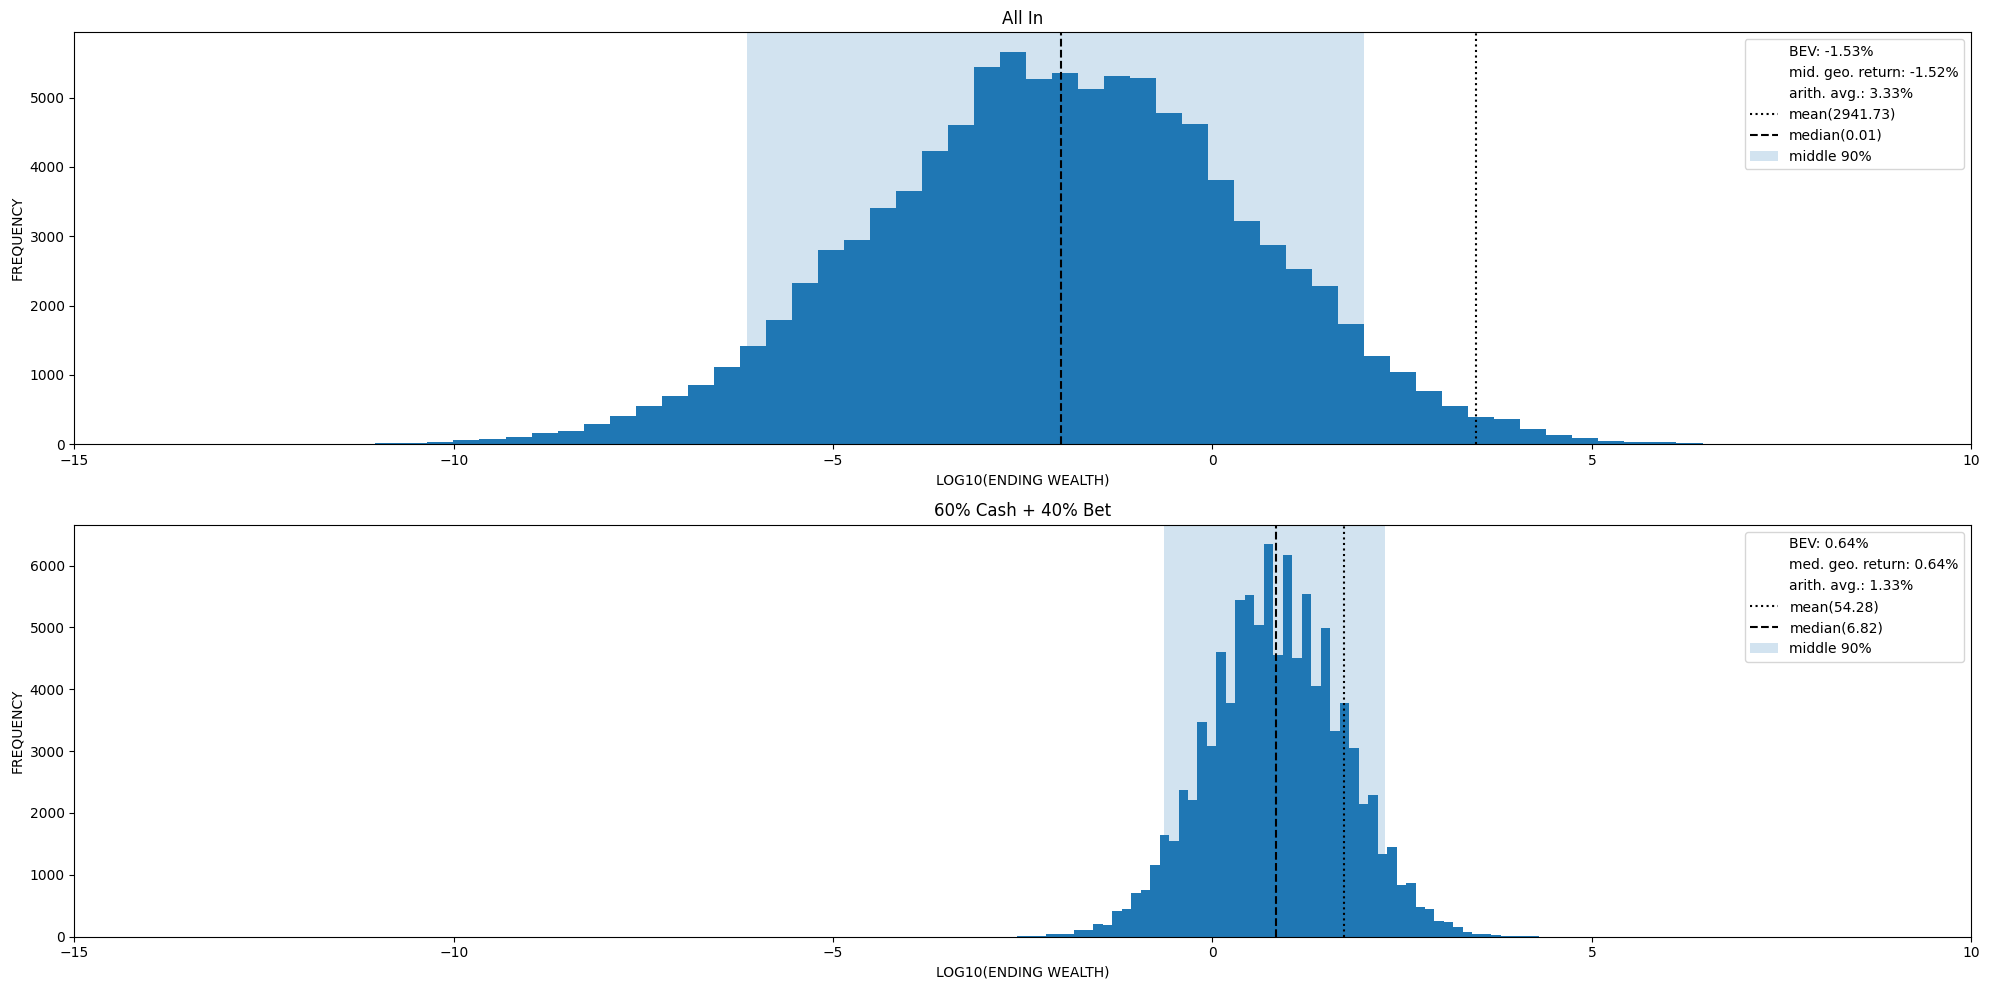

In [ ]:
payoffs = np.asarray([-0.5, 0.05, 0.05, 0.05, 0.05, 0.5])

samples = 100000
bets = 300
fig, (subfig1, subfig2) = plt.subplots(2, 1, figsize=(20, 10))

# ------- All In
ending_wealths = np.prod(1 + payoffs[np.random.randint(0, len(payoffs), (samples, bets))], axis=1)
mean = np.mean(ending_wealths)
median = np.median(ending_wealths)
ending_wealth_log = np.log10(ending_wealths)

p5, p95 = np.percentile(ending_wealth_log, [5, 95])
bev = np.exp(np.sum(np.log(1+payoffs))/np.size(payoffs)) - 1
median_geometric_return = median ** (1 / bets) - 1

arithmetic_avg = np.mean(1 + payoffs) - 1
print(f'arithmetic average: {arithmetic_avg * 100:.2f}%')

subfig1.hist(ending_wealth_log, bins=60)
subfig1.set_xlim(-15, 10)
# legend-only text entries
subfig1.plot([], [], ' ', label=f'BEV: {bev:.2%}')
subfig1.plot([], [], ' ', label=f'mid. geo. return: {median_geometric_return:.2%}')
subfig1.plot([], [], ' ', label=f'arith. avg.: {arithmetic_avg * 100:.2f}%')

subfig1.axvline(np.log10(mean), linestyle='dotted', color='black', label=f'mean({mean:.2f})')
subfig1.axvline(np.log10(median), linestyle='dashed', color='black', label=f'median({median:.2f})')
subfig1.axvspan(p5, p95, alpha=0.2, label="middle 90%")

subfig1.set_title("All In")
subfig1.set_xlabel("LOG10(ENDING WEALTH)")
subfig1.set_ylabel("FREQUENCY")
subfig1.legend()

# ------- 60% cash
cash_ratio = 0.6

ending_wealths = np.prod(
    (1-cash_ratio) * (1 + payoffs[np.random.randint(0, len(payoffs), (samples, bets))]) + cash_ratio,
    axis=1)

mean = np.mean(ending_wealths)
median = np.median(ending_wealths)
ending_wealth_log = np.log10(ending_wealths)

p5, p95 = np.percentile(ending_wealth_log, [5, 95])
bev = np.exp(np.sum(np.log(cash_ratio+(1-cash_ratio)*(1+payoffs)))/np.size(payoffs)) - 1
median_geometric_return = median ** (1 / bets) - 1
arithmetic_avg = np.mean(cash_ratio + (1-cash_ratio) * (1+payoffs)) - 1

subfig2.hist(ending_wealth_log, bins=60)
subfig2.set_xlim(-15, 10)
# legend-only text entries
subfig2.plot([], [], ' ', label=f'BEV: {bev:.2%}')
subfig2.plot([], [], ' ', label=f'med. geo. return: {median_geometric_return:.2%}')
subfig2.plot([], [], ' ', label=f'arith. avg.: {arithmetic_avg * 100:.2f}%')

subfig2.axvline(np.log10(mean), linestyle='dotted', color='black', label=f'mean({mean:.2f})')
subfig2.axvline(np.log10(median), linestyle='dashed', color='black', label=f'median({median:.2f})')
subfig2.axvspan(p5, p95, alpha=0.2, label="middle 90%")

subfig2.set_title("60% Cash + 40% Bet")
subfig2.set_xlabel("LOG10(ENDING WEALTH)")
subfig2.set_ylabel("FREQUENCY")
subfig2.legend()

fig.tight_layout()
fig.show()